In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv('train.csv')


df['datetime'] = pd.to_datetime(df['datetime'])


df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day
df['hour'] = df['datetime'].dt.hour

# 3. 불필요한 컬럼 및 정보 누수(Leakage) 방지를 위한 컬럼 제거
# - datetime: 이미 쪼갰으므로 삭제
# - casual, registered: 두 값을 더하면 정답(count)이 되므로, 예측 시엔 쓸 수 없는 '반칙' 데이터. 무조건 삭제
df.drop(['datetime', 'casual', 'registered'], axis=1, inplace=True, errors='ignore')

# 가공된 데이터 확인
df.head()


,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,year,month,day,hour
0,1,0,0,1,9.84,14.395,81,0.0,16,2011,1,1,0
1,1,0,0,1,9.02,13.635,80,0.0,40,2011,1,1,1
2,1,0,0,1,9.02,13.635,80,0.0,32,2011,1,1,2
3,1,0,0,1,9.84,14.395,75,0.0,13,2011,1,1,3
4,1,0,0,1,9.84,14.395,75,0.0,1,2011,1,1,4


In [6]:
df = pd.read_csv('train.csv')

In [1]:
import os
print(os.listdir()) # 현재 폴더에 있는 파일 목록을 출력합니다.

['(교수).ipynb', ',', '.ipynb_checkpoints', '201601_201601_연령별인구현황_월간.xlsx', '201601_201606_주민등록인구및세대현황_월간.xlsx', '2016년 인구피라미드.png', '202601_202601_연령별인구현황_월간.xlsx', 'APT_FeatureEng.ipynb', 'APT_FeatureEng_결과값.ipynb', 'APT_FeatureEng결과.ipynb', 'Bike Sharing Demand.ipynb', 'Boolean Indexing.ipynb', 'd0203.txt', 'DataFrame_index key.ipynb', 'DataFrame_index-2.ipynb', 'DataFrame_index.ipynb', 'DataFrame_index1.ipynb', 'feature_eng.ipynb', 'feature_eng_결과.ipynb', 'feature_eng결과.ipynb', 'file_io.ipynb', 'file_io1.ipynb', 'gender_submission.csv', 'gwangju_data.csv', 'iris_DecisionTree(교수).ipynb', 'iris_DecisionTree.ipynb', 'iris_DecisionTree01.ipynb', 'mytest01.ipynb', 'pandas01-1.ipynb', 'quotes_all.csv', 'quotes_simple.csv', 're 연습 (1).ipynb', 're 연습 (2)(교수).ipynb', 're 연습 (2).ipynb', 're 연습.ipynb', 're연습(1).ipynb', 'score.csv', 'score.txt', 'Selenium 실습(교수).ipynb', 'Selenium 실습.ipynb', 'test.csv', 'test02.ipynb', 'test03.ipynb', 'titanic.ipynb', 'titanic.zip', 'Titanic1(전처리).ipynb', 'Titan

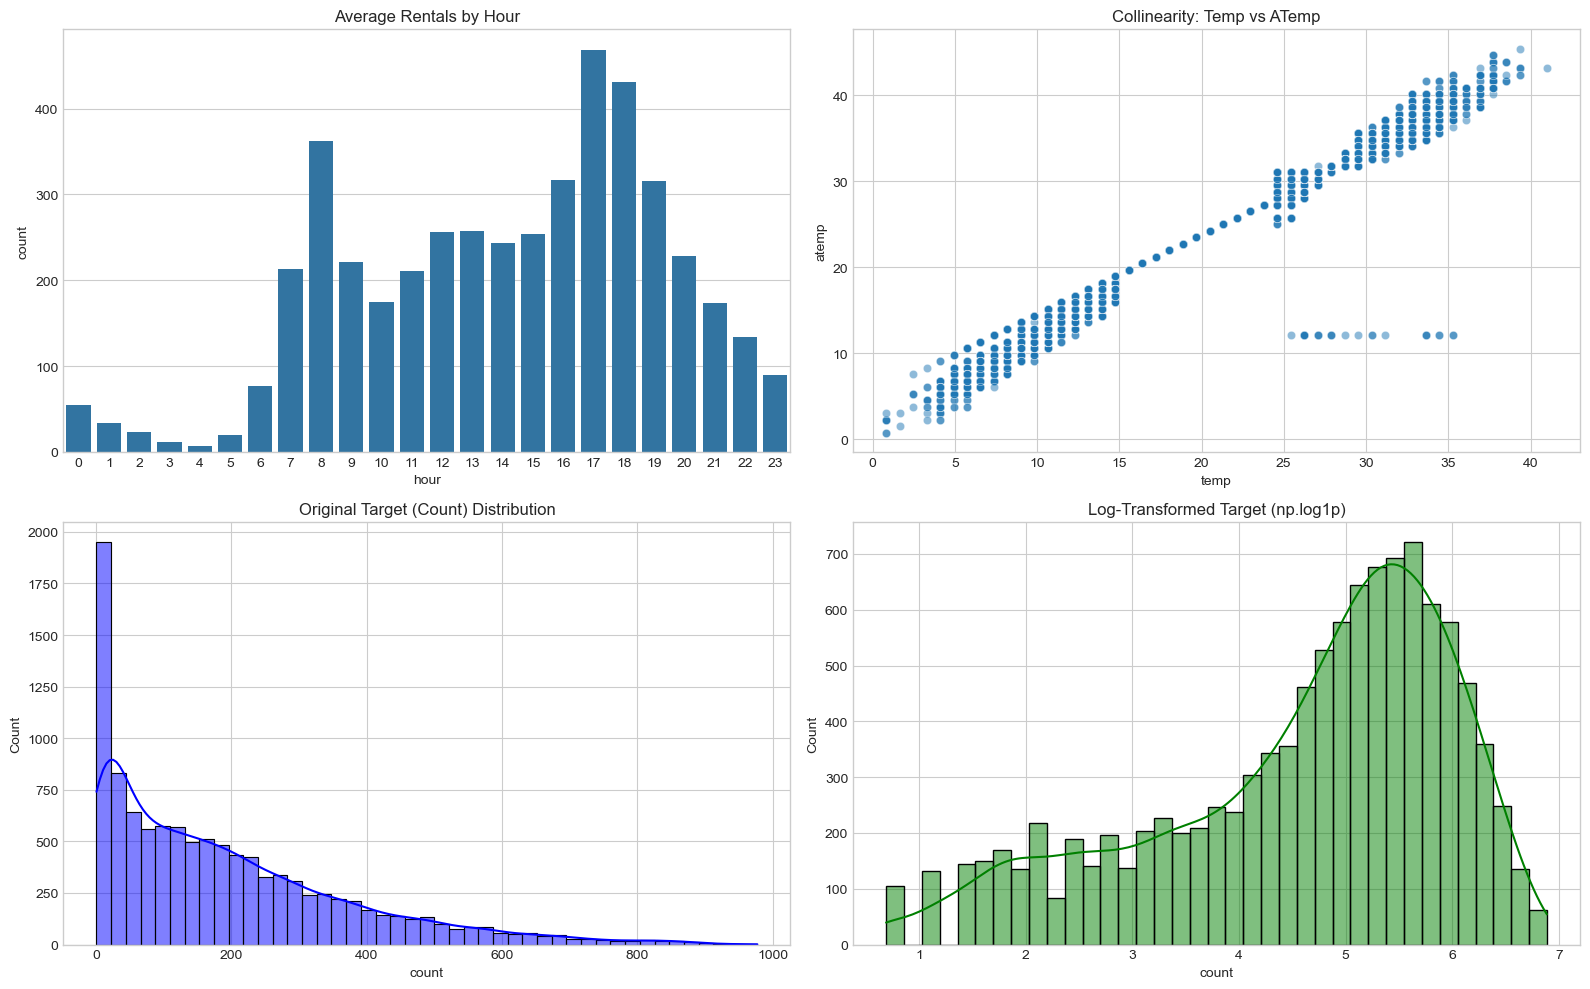

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화 전역 설정 (깔끔한 테마 적용)
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))

# -----------------------------------------------------------
# [그래프 1] 시간대(Hour)별 대여량
# 왜 중요한가?: 자전거 대여의 핵심은 '출퇴근 시간'입니다. 
# 오전 8시, 오후 6시 부근에서 피크를 찍는지 확인합니다.
# -----------------------------------------------------------
sns.barplot(x='hour', y='count', data=df, ax=axes[0, 0], errorbar=None)
axes[0, 0].set_title('Average Rentals by Hour')

# -----------------------------------------------------------
# [그래프 2] 온도(temp)와 체감온도(atemp)의 다중공선성 확인
# 왜 중요한가?: 두 수치가 너무 똑같이 움직이면(강한 상관관계) 모델에 혼란을 줄 수 있습니다.
# 선형으로 뚜렷하게 나타난다면 하나를 제거하는 것을 고려할 수 있습니다.
# -----------------------------------------------------------
sns.scatterplot(x='temp', y='atemp', data=df, ax=axes[0, 1], alpha=0.5)
axes[0, 1].set_title('Collinearity: Temp vs ATemp')

# -----------------------------------------------------------
# [그래프 3] 정답 데이터(count)의 원본 분포
# 왜 중요한가?: 데이터가 왼쪽으로 쏠려있고(Right-skewed) 
# 아주 큰 값(이상치)들이 꼬리를 길게 늘어뜨리고 있는지 확인합니다.
# -----------------------------------------------------------
sns.histplot(df['count'], kde=True, ax=axes[1, 0], color='blue')
axes[1, 0].set_title('Original Target (Count) Distribution')

# -----------------------------------------------------------
# [그래프 4] 정답 데이터(count)의 로그 변환 (np.log1p) 분포
# 왜 중요한가?: 저번 시간에 배운 RMSLE 평가 지표를 위해 타겟에 로그를 씌워 
# 분포를 정규분포(종 모양)에 가깝게 예쁘게 펴주는 작업입니다.
# -----------------------------------------------------------
sns.histplot(np.log1p(df['count']), kde=True, ax=axes[1, 1], color='green')
axes[1, 1].set_title('Log-Transformed Target (np.log1p)')

plt.tight_layout()
plt.show()

In [10]:
# 1. datetime 컬럼을 판다스 날짜/시간 타입으로 변환
df['datetime'] = pd.to_datetime(df['datetime'])

# 2. 날짜 데이터에서 각각 연, 월, 일, 시간 컬럼을 추출하여 새로 생성
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day
df['hour'] = df['datetime'].dt.hour

# 변환이 잘 되었는지 확인
df.head()


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,1
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,1,1,2
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011,1,1,3
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011,1,1,4


In [12]:
df.head

<bound method NDFrame.head of                  datetime  season  holiday  workingday  weather   temp  \
0     2011-01-01 00:00:00       1        0           0        1   9.84   
1     2011-01-01 01:00:00       1        0           0        1   9.02   
2     2011-01-01 02:00:00       1        0           0        1   9.02   
3     2011-01-01 03:00:00       1        0           0        1   9.84   
4     2011-01-01 04:00:00       1        0           0        1   9.84   
...                   ...     ...      ...         ...      ...    ...   
10881 2012-12-19 19:00:00       4        0           1        1  15.58   
10882 2012-12-19 20:00:00       4        0           1        1  14.76   
10883 2012-12-19 21:00:00       4        0           1        1  13.94   
10884 2012-12-19 22:00:00       4        0           1        1  13.94   
10885 2012-12-19 23:00:00       4        0           1        1  13.12   

        atemp  humidity  windspeed  casual  registered  count  year  month  \
0  

In [13]:
# 1. 데이터 클렌징 및 가공 (Data Cleaning & Feature Engineering)
#     데이터를 모델이 이해할 수 있는 형태로 다듬는 과정입니다.

# 타입 변환: object(문자열)였던 datetime을 datetime64 타입으로 바꿔서 컴퓨터가 인식하게 함.
# 피처 추출 (Feature Extraction): 덩어리 날짜 데이터에서 연(Year), 월(Month), 일(Day), 시(Hour)를 각각 뽑아냄. (이게 모델 성능을 결정짓는 핵심!)
# 불필요한 데이터 제거: casual(비회원), registered(회원)는 합치면 정답(count)이 되기 때문에, 미래 예측 시에는 알 수 없는 정보라 미리 삭제함 (Data Leakage 방지).
# 2. 시각화 (Visualization & EDA)
# 데이터 속에 숨겨진 "이야기"를 눈으로 확인하는 과정입니다.

# Bar Plot (막대 그래프): 시간대별 대여량을 그려보니 **"출퇴근 시간에 대여가 폭발한다"**는 패턴 발견 (가장 중요한 인사이트).
# Scatter Plot (산점도): 온도(temp)와 체감온도(atemp)를 그려보니 **"둘이 거의 똑같이 움직인다(다중공선성)"**는 사실 발견 (둘 중 하나만 써도 된다는 힌트).
# Dist Plot (분포도): 전체 대여량(count)이 한쪽(0 부근)에 몰려 있는 것을 확인 -> **로그 변환(Log Transformation)**이 필요함을 직관적으로 파악.

In [14]:
from sklearn.model_selection import train_test_split

# 1. 훈련에 사용할 피처(특성) 선택
features = ['year', 'month', 'hour', 'workingday', 'holiday', 'weather', 
            'temp', 'atemp', 'humidity', 'windspeed']

# 2. X(문제)와 y(정답) 분리
X = df[features]
y = df['count']

# 3. 타겟을 로그 변환 (RMSLE 대비 & 분포 정규화)
y_log = np.log1p(y)

# 4. 학습용 80% / 검증용 20%로 분할
# random_state=42는 "랜덤 고정값" → 실행할 때마다 같은 결과가 나오게 고정
X_train, X_val, y_train, y_val = train_test_split(
    X, y_log, 
    test_size=0.2,      # 검증 데이터 비율 20%
    random_state=42     # 재현성을 위한 시드 고정
)

# 5. 분할 결과 확인
X_train.shape, X_val.shape


((8708, 10), (2178, 10))

In [15]:
# 앞에 !를 붙여서 주피터 노트북 내에서 터미널 명령어를 실행합니다.
!pip install xgboost lightgbm

Defaulting to user installation because normal site-packages is not writeable


In [16]:
from xgboost import XGBRegressor

# 모델 생성
model = XGBRegressor(random_state=42)

# 학습
model.fit(X_train, y_train)

# 검증 데이터로 예측
y_pred_log = model.predict(X_val)

# 로그 역변환 (원래 숫자로 되돌리기)
y_pred = np.expm1(y_pred_log)
y_val_original = np.expm1(y_val)

In [20]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. 모델 생성 및 학습
xgb_model = XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)

# 2. 검증 데이터로 예측 (로그값 상태)
y_pred_log = xgb_model.predict(X_val)

# 3. 로그 역변환 (원래 자전거 대수 숫자로 복구)
y_pred = np.expm1(y_pred_log)
y_val_original = np.expm1(y_val)

# 4. RMSLE 계산 (캐글 평가지표)
# 로그 스케일 데이터(y_train, y_val)의 RMSE는 원본 데이터의 RMSLE와 같습니다.
rmsle = np.sqrt(mean_squared_error(y_val, y_pred_log))


In [18]:
print

<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [19]:
# 결과 확인
rmsle

np.float64(0.30641199654379686)

In [21]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np

# 1. 모델 객체 생성
# Ridge와 Lasso는 규제(Regularization)를 통해 과적합을 방지하는 선형 모델입니다.
lr_model = LinearRegression()
ridge_model = Ridge(alpha=1.0, random_state=42)
lasso_model = Lasso(alpha=0.01, random_state=42)

# 2. 선형 회귀 학습 및 평가
lr_model.fit(X_train, y_train)
lr_pred_log = lr_model.predict(X_val)
lr_rmsle = np.sqrt(mean_squared_error(y_val, lr_pred_log))

# 3. 릿지(Ridge) 학습 및 평가
ridge_model.fit(X_train, y_train)
ridge_pred_log = ridge_model.predict(X_val)
ridge_rmsle = np.sqrt(mean_squared_error(y_val, ridge_pred_log))

# 4. 라쏘(Lasso) 학습 및 평가
lasso_model.fit(X_train, y_train)
lasso_pred_log = lasso_model.predict(X_val)
lasso_rmsle = np.sqrt(mean_squared_error(y_val, lasso_pred_log))

# 5. 결과를 데이터프레임으로 깔끔하게 정리 (print 생략)
linear_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso'],
    'RMSLE': [lr_rmsle, ridge_rmsle, lasso_rmsle]
})

linear_results


,Model,RMSLE
0,Linear Regression,1.025849
1,Ridge,1.025845
2,Lasso,1.025899


In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. 모델 객체 생성 (n_estimators: 트리 개수, n_jobs: 모든 CPU 코어 사용)
rf_model = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)

# 2. 모델 학습
rf_model.fit(X_train, y_train)

# 3. 검증 데이터로 예측 (로그값 상태)
rf_pred_log = rf_model.predict(X_val)

# 4. RMSLE 계산 (이미 로그 변환된 y_val과 비교하므로 RMSE 결과가 곧 RMSLE입니다)
rf_rmsle = np.sqrt(mean_squared_error(y_val, rf_pred_log))

# 5. 결과 확인 (선형 회귀 결과들과 비교해 보세요!)
rf_rmsle


np.float64(0.3271212941494455)

In [23]:
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor

# 1. GBM 모델
gbm_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gbm_model.fit(X_train, y_train)
gbm_rmsle = np.sqrt(mean_squared_error(y_val, gbm_model.predict(X_val)))

# 2. LightGBM 모델
lgbm_model = LGBMRegressor(n_estimators=100, random_state=42)
lgbm_model.fit(X_train, y_train)
lgbm_rmsle = np.sqrt(mean_squared_error(y_val, lgbm_model.predict(X_val)))

# 결과 비교 (print 없이 결과 확인)
pd.DataFrame({'Model': ['GBM', 'LightGBM'], 'RMSLE': [gbm_rmsle, lgbm_rmsle]})


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000175 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 262
[LightGBM] [Info] Number of data points in the train set: 8708, number of used features: 10
[LightGBM] [Info] Start training from score 4.593780


,Model,RMSLE
0,GBM,0.398305
1,LightGBM,0.315775
